# ApexPlanet Data Analytics Internship — Task 3
## Data Visualization & Dashboarding

**Dataset:** Superstore Sales  
**Tools:** Python, Matplotlib, Seaborn, Plotly, Power BI

This notebook covers the Python visualization part of Task 3 and provides the exact design, KPIs, DAX measures, and checklist for the Power BI dashboard.


In [1]:
# Install if required
# !pip install pandas numpy matplotlib seaborn plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.read_csv("Superstore_Cleaned_Task1.csv")
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")
df["Ship_Date"] = pd.to_datetime(df["Ship_Date"], errors="coerce")

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (8399, 21)


,Row_ID,Order_ID,Order_Date,Order_Priority,Order_Quantity,Sales,Discount,Ship_Mode,Profit,Unit_Price,Shipping_Cost,Customer_Name,Province,Region,Customer_Segment,Product_Category,Product_Sub_Category,Product_Name,Product_Container,Product_Base_Margin,Ship_Date
0,1,3,2010-10-13,Low,6,261.5400,0.04,Regular Air,-213.25,38.94,35.00,Muhammed MacIntyre,Nunavut,Nunavut,Small Business,Office Supplies,Storage & Organization,"Eldon Base for stackable storage shelf, platinum",Large Box,0.80,2010-10-20
1,49,293,2012-10-01,High,49,10123.0200,0.07,Delivery Truck,457.81,208.16,68.02,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,"1.7 Cubic Foot Compact ""Cube"" Office Refrigera...",Jumbo Drum,0.58,2012-10-02
2,50,293,2012-10-01,High,27,244.5700,0.01,Regular Air,46.71,8.69,2.99,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Binders and Binder Accessories,"Cardinal Slant-D® Ring Binder, Heavy Gauge Vinyl",Small Box,0.39,2012-10-03
3,80,483,2011-07-10,High,30,4965.7595,0.08,Regular Air,1198.97,195.99,3.99,Clay Rozendal,Nunavut,Nunavut,Corporate,Technology,Telephones and Communication,R380,Small Box,0.58,2011-07-12
4,85,515,2010-08-28,Not Specified,19,394.2700,0.08,Regular Air,30.94,21.78,5.94,Carlos Soltero,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,Holmes HEPA Air Purifier,Medium Box,0.50,2010-08-30


## 1. KPI Analysis

In [2]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order_ID"].nunique()
total_customers = df["Customer_Name"].nunique()
total_quantity = df["Order_Quantity"].sum()
profit_margin = total_profit / total_sales * 100

kpis = pd.DataFrame({
    "KPI": ["Total Sales", "Total Profit", "Total Orders", "Total Customers", "Total Quantity", "Profit Margin (%)"],
    "Value": [total_sales, total_profit, total_orders, total_customers, total_quantity, profit_margin]
})
display(kpis)


,KPI,Value
0,Total Sales,1.491560e+07
1,Total Profit,1.521768e+06
2,Total Orders,5.496000e+03
3,Total Customers,7.950000e+02
4,Total Quantity,2.147770e+05
5,Profit Margin (%),1.020253e+01


## 2. Matplotlib Visualizations

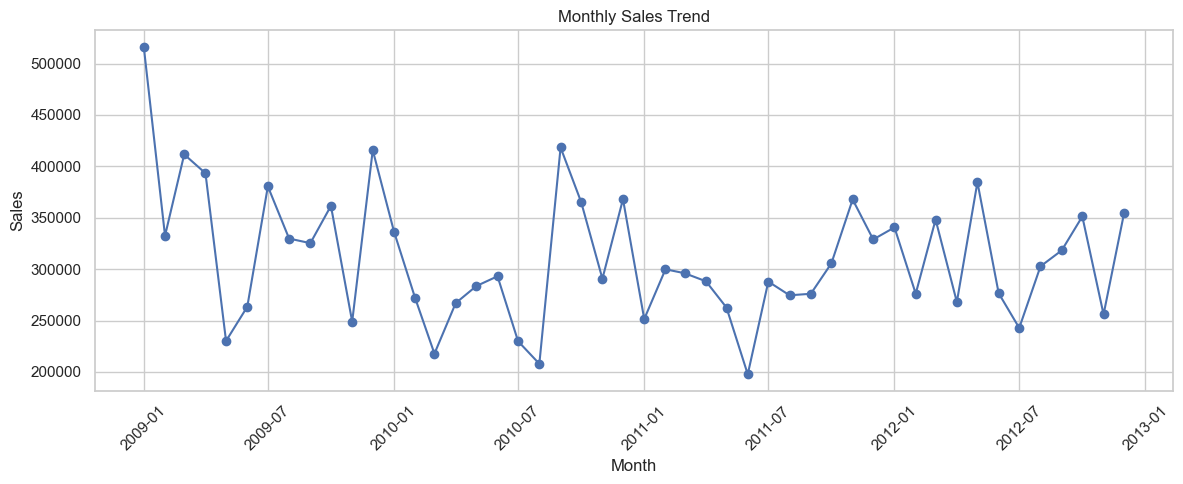

In [3]:
# Monthly sales trend
monthly_sales = df.set_index("Order_Date").resample("MS")["Sales"].sum().reset_index()

plt.figure(figsize=(12,5))
plt.plot(monthly_sales["Order_Date"], monthly_sales["Sales"], marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


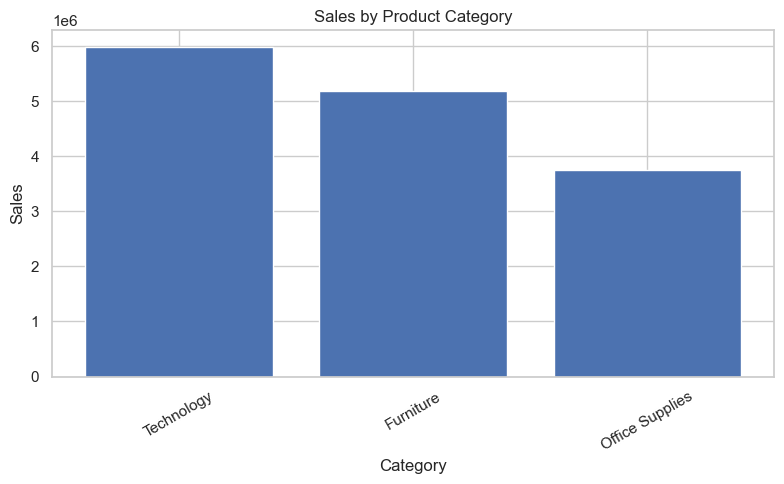

In [4]:
# Sales by product category
category_sales = df.groupby("Product_Category", as_index=False).agg(
    Total_Sales=("Sales","sum"),
    Total_Profit=("Profit","sum")
).sort_values("Total_Sales", ascending=False)

plt.figure(figsize=(8,5))
plt.bar(category_sales["Product_Category"], category_sales["Total_Sales"])
plt.title("Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


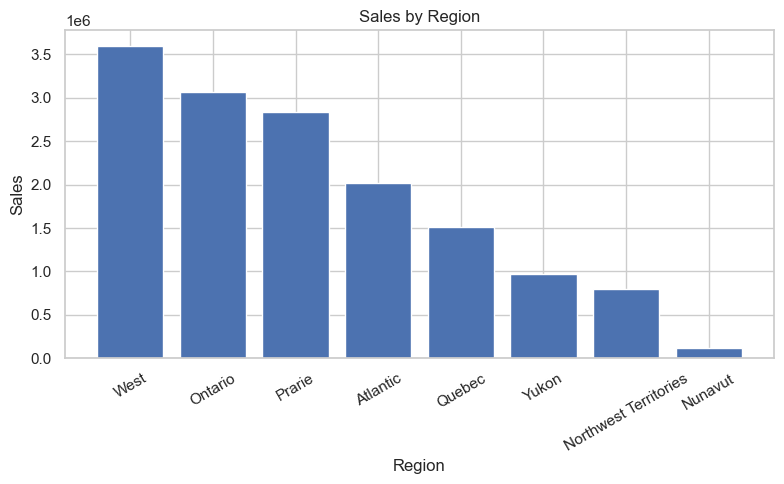

In [5]:
# Sales by region
region_sales = df.groupby("Region", as_index=False).agg(
    Total_Sales=("Sales","sum"),
    Total_Profit=("Profit","sum")
).sort_values("Total_Sales", ascending=False)

plt.figure(figsize=(8,5))
plt.bar(region_sales["Region"], region_sales["Total_Sales"])
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


C:\Users\rahul\AppData\Local\Temp\ipykernel_7820\3811945230.py:9: UserWarning: Glyph 153 (\x99) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\rahul\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 153 (\x99) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


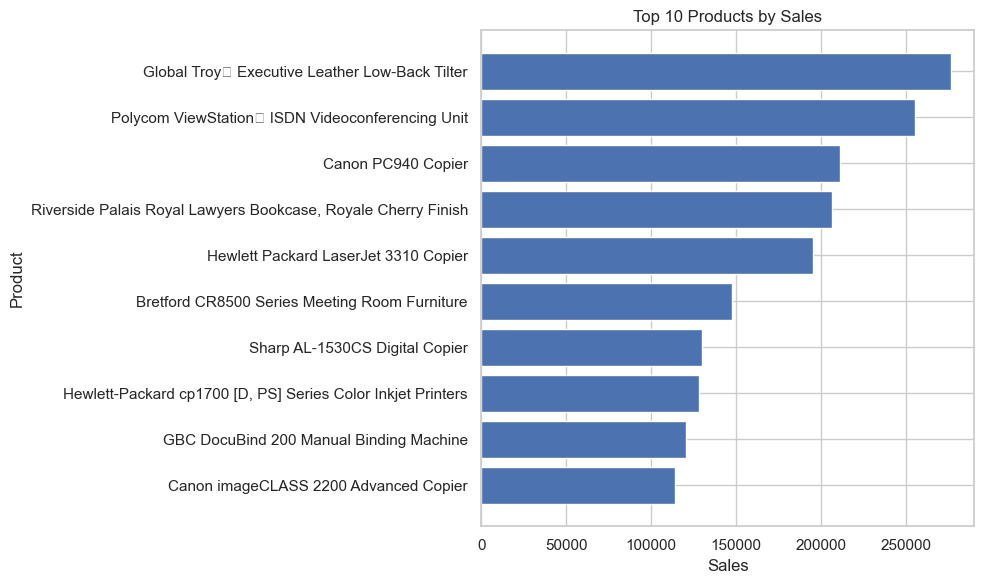

In [6]:
# Top 10 products
top_products = df.groupby("Product_Name")["Sales"].sum().sort_values(ascending=False).head(10).sort_values()

plt.figure(figsize=(10,6))
plt.barh(top_products.index, top_products.values)
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.show()


## 3. Seaborn Advanced Visualizations

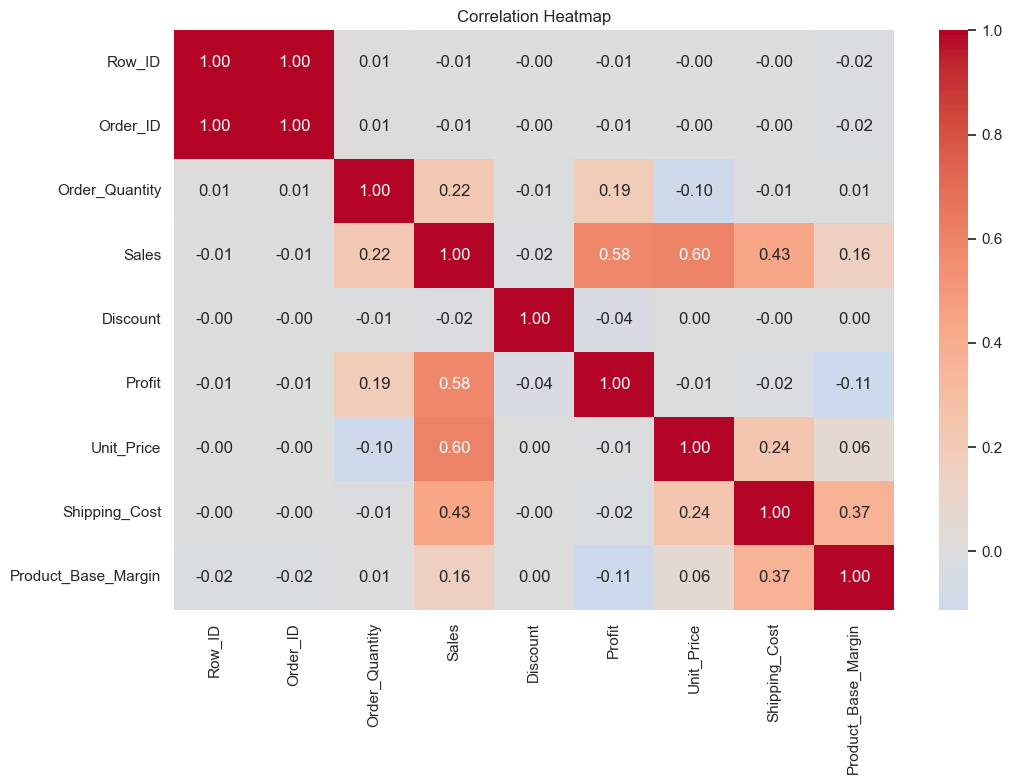

In [7]:
# Correlation heatmap
numeric_cols = df.select_dtypes(include=np.number).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(11,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


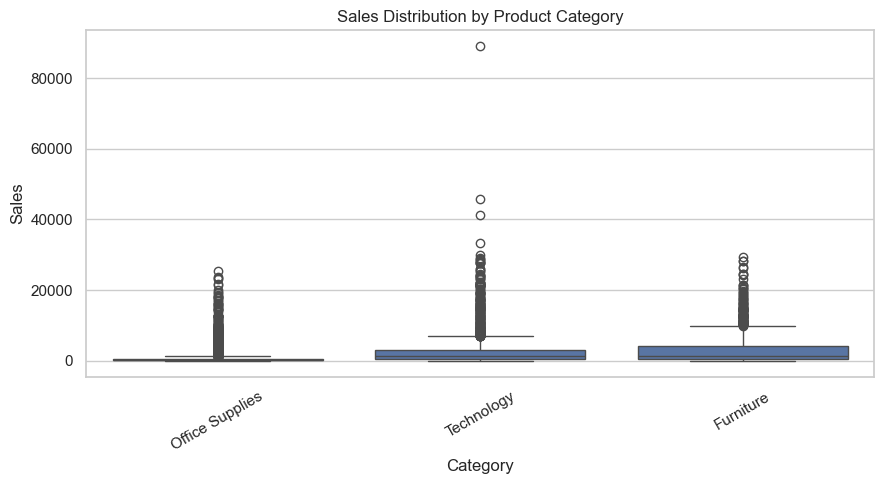

In [8]:
# Sales distribution by category
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x="Product_Category", y="Sales")
plt.title("Sales Distribution by Product Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 4. Plotly Interactive Visualizations

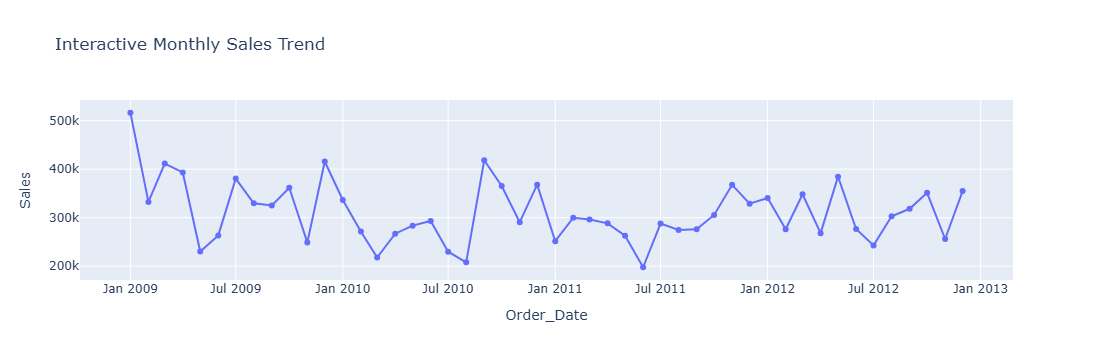

In [9]:
fig = px.line(monthly_sales, x="Order_Date", y="Sales", markers=True,
              title="Interactive Monthly Sales Trend")
fig.show()


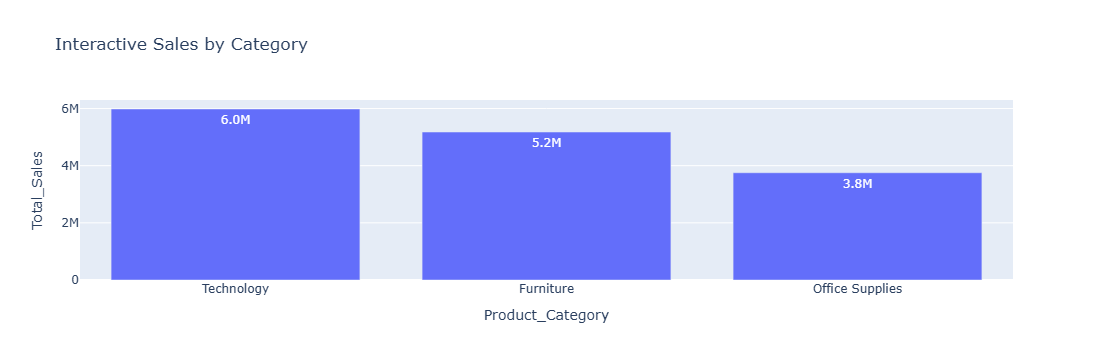

In [10]:
fig = px.bar(category_sales, x="Product_Category", y="Total_Sales",
              title="Interactive Sales by Category", text_auto=".2s")
fig.show()


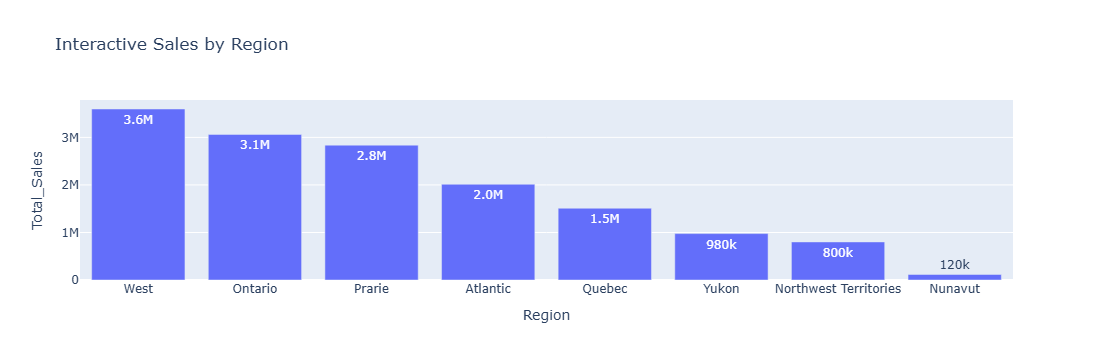

In [11]:
fig = px.bar(region_sales, x="Region", y="Total_Sales",
              title="Interactive Sales by Region", text_auto=".2s")
fig.show()


## 5. Power BI Dashboard Design

### KPI Cards
1. Total Sales
2. Total Profit
3. Total Orders
4. Total Customers

### Main visuals
5. Monthly Sales Trend — Line Chart
6. Sales by Category — Bar/Donut Chart
7. Sales by Region — Bar Chart or Map
8. Top 10 Products — Bar Chart

### Slicers
- Order Date
- Region
- Product Category
- Customer Segment
- Ship Mode

### Recommended layout
**Row 1:** Total Sales | Total Profit | Total Orders | Total Customers

**Row 2:** Monthly Sales Trend | Sales by Category

**Row 3:** Sales by Region | Top 10 Products

The ApexPlanet document requires a professional dashboard with 6–8 visuals, KPI cards, sales trend, category breakdown, geographic analysis where location data exists, Top 10 analysis, filters, and a shareable dashboard. 


## 6. Power BI DAX Measures

In [14]:
Total_Sales = df['Sales'].sum()
Total_Profit = df['Profit'].sum()
Total_Orders = df['Order_ID'].nunique()
Total_Customers = df['Customer_Name'].nunique()
Total_Quantity = df['Order_Quantity'].sum()

Profit_Margin = Total_Profit / Total_Sales
Average_Order_Value = Total_Sales / Total_Orders

print("Total Sales:", Total_Sales)
print("Total Profit:", Total_Profit)
print("Total Orders:", Total_Orders)
print("Total Customers:", Total_Customers)
print("Total Quantity:", Total_Quantity)
print("Profit Margin %:", Profit_Margin * 100)
print("Average Order Value:", Average_Order_Value)


Total Sales: 14915600.824000001
Total Profit: 1521767.98
Total Orders: 5496
Total Customers: 795
Total Quantity: 214777
Profit Margin %: 10.20252551644714
Average Order Value: 2713.9011688500727


## 7. Task 3 Submission Checklist

- [ ] Python visualization notebook
- [ ] PNG/HTML visualizations where required
- [ ] Power BI `.pbix` dashboard
- [ ] 6–8 dashboard visuals
- [ ] KPI cards
- [ ] Sales trend
- [ ] Category breakdown
- [ ] Regional/geographic analysis
- [ ] Top 10 products
- [ ] Slicers and filters
- [ ] Dashboard screenshot
- [ ] Power BI shareable link, if required

### LinkedIn draft
Task 3 complete at @ApexPlanet! Built an interactive sales dashboard using Power BI and Python, covering key KPIs, sales trends, category performance, regional analysis, and top products. #PowerBI #DataVisualization #DataAnalytics
